In [3]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download once
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

print("✅ Libraries loaded")

✅ Libraries loaded


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\samia\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# STEP 2: Load Datasets
true_df = pd.read_csv('true.csv')
fake_df = pd.read_csv('fake.csv')
news_df = pd.read_csv('news_data.csv')

print("✅ Data loaded")
print("True:", true_df.shape)
print("Fake:", fake_df.shape)
print("News:", news_df.shape)

✅ Data loaded
True: (21417, 4)
Fake: (23481, 4)
News: (4009, 4)


In [5]:
# STEP 3: Quick Inspection
print("\nTrue columns:", true_df.columns)
print("\nFake columns:", fake_df.columns)
print("\nNews columns:", news_df.columns)

print("\nSample news data:")
print(news_df.head(3))


True columns: Index(['title', 'text', 'subject', 'date'], dtype='object')

Fake columns: Index(['title', 'text', 'subject', 'date'], dtype='object')

News columns: Index(['URLs', 'Headline', 'Body', 'Label'], dtype='object')

Sample news data:
                                                URLs  \
0  http://www.bbc.com/news/world-us-canada-414191...   
1  https://www.reuters.com/article/us-filmfestiva...   
2  https://www.nytimes.com/2017/10/09/us/politics...   

                                            Headline  \
0         Four ways Bob Corker skewered Donald Trump   
1  Linklater's war veteran comedy speaks to moder...   
2  Trump’s Fight With Corker Jeopardizes His Legi...   

                                                Body  Label  
0  Image copyright Getty Images\nOn Sunday mornin...      1  
1  LONDON (Reuters) - “Last Flag Flying”, a comed...      1  
2  The feud broke into public view last week when...      1  


In [6]:
# STEP 4: Preprocess NEWS dataset
# Rename columns
news_df = news_df.rename(columns={
    'Label': 'label',
    'Body': 'body',
    'Headline': 'headline'
})

# Remove duplicates
news_df = news_df.drop_duplicates()

# Handle missing values
news_df['body'] = news_df['body'].fillna('')
news_df['headline'] = news_df['headline'].fillna('')

# Combine text
news_df['text'] = news_df['headline'] + " " + news_df['body']

# Keep only needed columns
news_df = news_df[['text', 'label']]

print("✅ News dataset prepared")

✅ News dataset prepared


In [7]:
# STEP 5: Prepare TRUE & FAKE datasets
true_data = true_df[['text']].copy()
true_data['label'] = 1

fake_data = fake_df[['text']].copy()
fake_data['label'] = 0

print("✅ True & Fake datasets prepared")

✅ True & Fake datasets prepared


In [8]:
# STEP 6: Text Cleaning Function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [9]:
# STEP 7: Apply Cleaning to ALL datasets
print("🔄 Cleaning news data...")
news_df['text'] = news_df['text'].apply(clean_text)

print("🔄 Cleaning true data...")
true_data['text'] = true_data['text'].apply(clean_text)

print("🔄 Cleaning fake data...")
fake_data['text'] = fake_data['text'].apply(clean_text)

print("✅ All text cleaned")

🔄 Cleaning news data...
🔄 Cleaning true data...
🔄 Cleaning fake data...
✅ All text cleaned


In [10]:
# STEP 8: Combine All Datasets
final_df = pd.concat([news_df, true_data, fake_data], axis=0)

# Shuffle
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Datasets merged")
print("Shape:", final_df.shape)

✅ Datasets merged
Shape: (48907, 2)


In [11]:
final_df.to_csv("final_fake_news_dataset.csv", index=False)

print("✅ Final dataset saved!")

✅ Final dataset saved!


In [12]:
# Step 9: Final cleaning
# Keeping only required columns
final_df = final_df[['text', 'label']].copy()

# Remove nulls
final_df = final_df.dropna(subset=['text', 'label'])

# Remove empty text
final_df = final_df[final_df['text'].str.strip() != ""]

# Remove duplicates
final_df = final_df.drop_duplicates()

# Reset index
final_df = final_df.reset_index(drop=True)
print("✅ Clean dataset shape:", final_df.shape)

✅ Clean dataset shape: (41979, 2)


In [13]:
print("\nLabel Distribution:")
print(final_df['label'].value_counts())


Label Distribution:
label
1    22786
0    19193
Name: count, dtype: int64


In [14]:
# step 10: Balanced dataset
df_fake = final_df[final_df['label'] == 0]
df_real = final_df[final_df['label'] == 1]

min_size = min(len(df_fake), len(df_real))

df_fake = df_fake.sample(min_size, random_state=42)
df_real = df_real.sample(min_size, random_state=42)

final_df = pd.concat([df_fake, df_real])
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced Distribution:")
print(final_df['label'].value_counts())


Balanced Distribution:
label
0    19193
1    19193
Name: count, dtype: int64


In [15]:
# step11: Define Features and Labels
X = final_df['text']
y = final_df['label']

print(len(X), len(y))  # MUST match

38386 38386


In [16]:
# Split BEFORE vectorization
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Step 12: Create TF-IDF and BoW vectors

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ---------------- TF-IDF ----------------
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Train:", X_train_tfidf.shape)
print("TF-IDF Test:", X_test_tfidf.shape)

# ---------------- Bag of Words ----------------
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW Train:", X_train_bow.shape)
print("BoW Test:", X_test_bow.shape)

TF-IDF Train: (30708, 5000)
TF-IDF Test: (7678, 5000)
BoW Train: (30708, 5000)
BoW Test: (7678, 5000)


In [19]:
#step 14: Train Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
print("\n---Logistic Regression ---")
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_tfidf, y_train)

print("✅ Model trained")

# Evaluate Model
lr_pred = lr_model.predict(X_test_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))


---Logistic Regression ---
✅ Model trained
Logistic Regression Accuracy: 0.9757749413909872


In [20]:
# Naive Bayes 
from sklearn.naive_bayes import MultinomialNB

print("\n--- Naive Bayes ---")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print("✅ Model trained")
nb_pred = nb_model.predict(X_test_tfidf)
# Evaluate
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))


--- Naive Bayes ---
✅ Model trained
Naive Bayes Accuracy: 0.9165147173743162


In [21]:
# SVM 
from sklearn.svm import LinearSVC
print("\n--- SVM ---")
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
print("✅ Model trained")
svm_pred = svm_model.predict(X_test_tfidf)
# Evaluate
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


--- SVM ---
✅ Model trained
SVM Accuracy: 0.9839802031779109


In [24]:
# Random Forest Model (using BoW features)

from sklearn.ensemble import RandomForestClassifier

print("\n--- Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bow, y_train)
print("✅ Model trained")
rf_pred = rf_model.predict(X_test_bow)
# Evaluate
print("Accuracy:", accuracy_score(y_test, rf_pred))


--- Random Forest ---
✅ Model trained
Accuracy: 0.9815056004167751


In [25]:
# Decision Tree Model (using BoW features)
from sklearn.tree import DecisionTreeClassifier
print("\n--- Decision Tree ---")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_bow, y_train)
print("✅ Model trained")
dt_pred = dt_model.predict(X_test_bow)

# Evaluate
print("Accuracy:", accuracy_score(y_test, dt_pred))


--- Decision Tree ---
✅ Model trained
Accuracy: 0.9802031779109143


In [26]:
# Gradient Boosting Model (using BoW features)

from sklearn.ensemble import GradientBoostingClassifier

print("\n--- Gradient Boosting ---")
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_bow.toarray(), y_train)
print("✅ Model trained")
gb_pred = gb_model.predict(X_test_bow.toarray())

# Evaluate
print("Accuracy:", accuracy_score(y_test, gb_pred))


--- Gradient Boosting ---
✅ Model trained
Accuracy: 0.9850221411825997


In [29]:
# Ensemble Model (Voting Classifier)

from sklearn.ensemble import VotingClassifier

print("\n--- Ensemble Model ---")

ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('dt', dt_model),
        ('gb', gb_model)
    ],
    voting='hard'
)

# Train (use dense because GB needs it)
ensemble_model.fit(X_train_bow.toarray(), y_train)
print("✅ Model trained")
# Predict
ensemble_pred = ensemble_model.predict(X_test_bow.toarray())

# Evaluate
print("Accuracy:", accuracy_score(y_test, ensemble_pred))


--- Ensemble Model ---
✅ Model trained
Accuracy: 0.9858035946861162


In [33]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Gradient Boosting": accuracy_score(y_test, gb_pred),
    "Ensemble": accuracy_score(y_test, ensemble_pred)
}
print("\n=== Model Accuracies ===")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


=== Model Accuracies ===
Logistic Regression: 0.9758
Naive Bayes: 0.9165
SVM: 0.9840
Random Forest: 0.9815
Decision Tree: 0.9802
Gradient Boosting: 0.9840
Ensemble: 0.9858


In [32]:
# Finding best model
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("\n🏆 Best Model:", best_model_name)
print("Accuracy:", best_accuracy)


🏆 Best Model: Ensemble
Accuracy: 0.9858035946861162


In [69]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3854
           1       0.99      0.98      0.99      3824

    accuracy                           0.99      7678
   macro avg       0.99      0.99      0.99      7678
weighted avg       0.99      0.99      0.99      7678



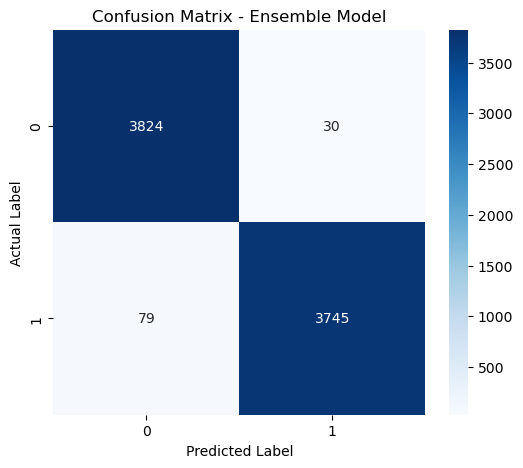

In [70]:
cm = confusion_matrix(y_test, ensemble_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Ensemble Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [35]:
model_map = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model,
    "Gradient Boosting": gb_model,
    "Ensemble": ensemble_model
}

best_model = model_map[best_model_name]

if best_model_name in ["Logistic Regression", "Naive Bayes", "SVM"]:
    best_vectorizer = tfidf_vectorizer
else:
    best_vectorizer = bow_vectorizer

In [66]:
import pickle

# Save best model
pickle.dump(best_model, open("model.pkl", "wb"))

# Save vectorizer (TF-IDF or BoW, depending on best model)
pickle.dump(best_vectorizer, open("vectorizer.pkl", "wb"))

print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!


In [36]:
# Final Prediction Function (Dynamic)
def predict_news(text):
    text = clean_text(text)
    vector = best_vectorizer.transform([text])

    # Convert to dense if needed
    if best_model_name in ["Gradient Boosting", "Ensemble"]:
        vector = vector.toarray()

    prediction = best_model.predict(vector)

    return "Real News" if prediction[0] == 1 else "Fake News"

In [42]:
print(predict_news("washington reuters democratic presidential nominee hillary clinton lead republican donald trump percentage point fourway race according fox news opinion poll released friday poll registered voter conducted tuesday thursday margin error plus minus percentage point fox news said clinton percent support trump percent clinton point week ago point midoctober fox news said"))

Real News


In [46]:
print(predict_news("washington reuters revised republican bill dismantle obamacare moving house representative would lead number american losing health insurance initial plan nonpartisan congressional budget office said thursday cbo said revised bill would raise number uninsured million compared current law analysis initial bill also said million american would end uninsured bitlymvmha"))

Real News


In [47]:
print(predict_news("end six point plain star presumptive republican nominee later released statement saying clinton criticism image attempt distract public dishonest behavior husband referring heavily criticized private meeting last week former president bill clinton attorney general loretta lynch investigation hillary clinton use private email server secretary state nears conclusion tweet came mic news reported sunday image attacking clinton included word history made inside star corrupt candidate ever shared neonazi web forum called pol reuters confirmed image posted june viewing link archived version pol page although page since updated image removed donald trump use blatantly antisemitic image racist website promote campaign would disturbing enough fact part pattern give voter major cause concern clinton presumptive democratic nominee said statement emailed reporter monday nazi forced jew wear star david clothing identify holocaust trump posted deleted tweet saturday tweeted similar image star replaced circle monday lashed journalist continuing report original tweet dishonest medium trying absolute best depict star tweet star david rather sheriff star plain star trump wrote twitter saturday incident latest departure trump recent effort appease republican worried brash public persona trying appear restrained republican convention trump expected named party nominee nov presidential election two week away june trump fired campaign manager corey lewandowski began using teleprompter make speech hoping show campaign could inclusive aroused controversy referring mexican crossing border illegally rapist mocking disabled reporter clinton begun using attack ad brookover senior adviser trump campaign said interview cnn monday campaign felt corrected issue star deleting trump original tweet brookover said image earlier appearance neonazi forum irrelevant image get posted reposted reposted social medium many forum said never intention antisemitism"))

Real News


In [48]:
print(predict_news("washington reuters president donald trump intends nominate dawn deberry stump former vice president nyse euronext serve commissioner commodity future trading commission white house said statement friday said stump president stump strategic consulting firm earlier worked senate committee agriculture nutrition forestry focused farm policy matter cftc"))

Real News


In [50]:
print(predict_news("anonymity eightyseven vote needed oust kuczynski congress passed motion start presidential vacancy proceeding last week vote wednesday thousand peruvian marched front congress denounce saw popular force bid exploit crisis sabotage country democratic institution pointing recent effort also oust attorney general justice constitutional court popular force emerged rightwing populist movement started former president alberto fujimori serving yearsentence graft human right crime autocratic government united state kuczynski held citizenship said peru strong democracy confident peruvian people institution address situation according peru constitutional norm state department bureau western hemisphere affair said political crisis stem disclosure brazilian builder odebrecht odbesul landed elite jail colombia dominican republic since acknowledging bribing official across region much century responding request congress odebrecht said paid million consulting company owned kuczynski close business associate decade starting deposit made company kuczynski owned minister government awarded odebrecht lucrative contract odebrecht said saturday indication transaction part past corrupt dealing politician discus prosecutor kuczynski strenuously denied ever tie odebrecht since apologized peru disclosing connection company blaming forgetfulness poor organization personal record decade work finance public administration said nothing improper payment careless sloppy defect nota tool dishonesty much much less crime kuczynski said kuczynski raised hope decade finance public administration experience would usher new period investment spur faster economic growth world copper producer sign crisis engulfed government peru postponed auction billion copper project scheduled wednesday february"))

Fake News


In [54]:
print(predict_news("sacramento calif reuters california governor jerry brown thursday nominated congressman xavier becerra attorney general highpowered pick signal state readiness defend progressive policy republican consolidate power washington choosing becerra brown tapping pragmatic reliably progressive democrat deep knowledge washington politics state top lawyer replace democrat kamala harris elected last month senate time california positioning respond anticipated conservative policy republican presidentelect donald trump california prosperity people currently threat hostile trump administration california senate leader kevin leon said thursday xavier serve guardian constitution ultimate check balance force division scapegoating mobilizing washington brown democrat particularly concerned trump congressional republican try roll back environmental protection reduce role effort combat climate change cited becerra someone could battle effort xavier outstanding public servant state legislature congress deputy attorney general brown said announcing appointment confident champion californian help state aggressively combat climate change appointment also take becerra running become ranking member congress powerful way mean committee statement released thursday outgoing ranking member sandy levin michigan democrat indicated position would filled representative richard neal massachusetts stanfordtrained lawyer becerra served california deputy attorney general winning seat congress representing northeastern section los angeles congress becerra rose chair house democratic caucus also served way mean committee national commission fiscal responsibility reform california right ahead country come clean energy commonsense treatment immigrant real health security much becerra said sacramento native said conference call reporter would welcome friendly overture trump republican control congress promised sharp pushback federal government try undo progressive policy immigration environment worker protection issue want take forwardleaning state prepared defend right interest come becerra said approved democraticmajority state legislature becerra replace harris resigns post join senate coming week harris also democrat replaces senator barbara boxer retiring"))

Real News


In [55]:
print(predict_news("reuters court vietnam jailed blogger monday seven year conducting propaganda state latest action critic oneparty state nguyen van hoa rose prominence toxic waste spill steel mill built taiwan formosa plastic corp vietnam unit polluted mile coast sparking rare protest communist partyruled country despite sweeping economic reform growing openness social change including gay lesbian transgender right vietnam retains tight medium censorship government tolerate criticism recent month authority stepped measure silence critic whose voice various issue amplified social medium country among facebook top user people court tinh province said website hoa found guilty propaganda state said hoa produced video call protest spill neither hoa legal family representative available comment hoa arrested prosecuted april publishing antigovernment content formosa incident one vietnam worst environmental disaster sensitive topic government balance political stability environmental protection foreign investment one driver economic growth government said prosecute identified formosa protester causing public disorder another critic steel mill spill nguyen ngoc nhu quynh known nam mother mushroom given year jail term publishing propaganda state prominent right lawyer represented quynh said monday bar federation phu yen province revoked licence practice government want work lawyer anymore defending poor people people unjustly charged case sensitive vietnam lawyer told reuters said would able defend quynh appeal hearing reuters unable immediately reach bar federation government authority comment case"))

Real News


In [56]:
print(predict_news("moscow reuters new sanction russia president donald trump signed law tantamount fullscale trade war russian prime minister dmitry medvedev said wednesday medvedev also said facebook post sanction showed trump administration utterly powerless hope relation new american administration would improve finished wrote"))

Real News


In [37]:
print(predict_news("Government announces new economic policy to reduce inflation"))

Fake News


In [60]:
print(predict_news("guess leftist millennials black life matter moron decided celebrate july even know history care video one best ever paul joseph watson language alertpaul joseph watson great job explaining america great wrong many leftist history racism genocide watson walk misconception america great stuff carrying mexican flag chanting trump president know america right language warningit funny brit know great america american citizen"))

Fake News


In [61]:
print(predict_news("classified material accusing extremely careless purposely distracted attention context email hillary bill clinton operated aggressive shakedown operation domestic foreign interest many unsavory criminal concealing true nature operation least part clinton motivation private serverthe outline uranium one deal secret medium outlet like new york time reported government approval partial sale canadian mining company rosatom russian firm benefitted donated clinton foundation paid bill clinton single speech moscowthen came detailed report fbi cracked case major russian effort penetrate north american uranium industry host illegal activity somehow whole matter slowwalked kept government official approve uranium one deal mueller comey ultimately supervised probemeanwhile fbi email investigation supervised nowfbi deputy director andrew mccabe significant connection clinton wife jill mccabe hillary headlined fundraiser group supporting jill mccabe campaign virginia state senate first reported wall street journal national legal policy center subsequently exposed clintonista support including thenclinton foundation operative doug band wrote personal check plot thickened last week bombshell hit hillary campaign democratic national committee paid fusion gps dossier reporter chagrined realize lied repeatedly month month hillary claim first heard dossier memo printed buzzfeed january likely lie long hillary know hillary know question interest mueller investigation credibility whatsoever therein lie dilemma mueller real probe hillary would mean review action colleague corneredmueller strategy clear rescue comey mccabe rosenstein others complicity hillary dealing russian mueller creating diversion going manafort lowest lowhanging fruit inquiry manafort dealing year sure yield resultsthe left leftist medium apoplectic possibility finally trump crosshairs problem medium smoke cleared truth revealed manafort indictment fact point president trump nothing democrat would love nothing see president trump fire special prosecutor robert mueller would prove guilty trumprussian narrative democrat ally medium pushing since night soundly defeated hillary clinton election upset century watch jay sekulow explain rabid cnn host wolf blitzer trump nothing either announcement indictment paul manafort campaign volunteer george papadopoulos"))

Fake News


In [62]:
print(predict_news("common descriptor breikss considers oppressive hateful language punishment repeatedly using banned word breikss warns includes limited removal class without attendance participation point failure assignment extreme case failure semester breikss wsu faculty member implementing policiesmuch like selena breikss classroom student taking professor rebecca fowler introduction comparative ethnic study course see grade suffer use term illegal alien assigned writingaccording syllabus student lose one point every time use word illegal alien illegals rather preferred term undocumented migrantsimmigrantspersons throughout course fowler say student come recognize white privilege function everyday social structure institution email campus reform fowler complained term illegal alien permeated dominant discourse circulate news extent society come associate unauthorized border crossing immigrant originating country south border asian immigrant example many also country without legal document make considerable portion undocumented immigrant living country sociolegal production migrant illegality work systematically dehumanize exploit brown body labor fowler continuedwhite student professor john streamas introduction multicultural literature class expected defer nonwhite student among community guideline want well class guideline syllabus streamas elaborates requires student reflect grasp history social relation respecting shy quiet classmate deferring experience people color streamas previously generated controversy calling student white shitbag declared wsu stand white supremacist university also demand student understand consider rage people victim systematic injustice later syllabus streamas go even accuses glenn beck insensitive white several wsu professor require student acknowledge racism classism sexism heterosexism institutionalized form oppression exist live postracial world ari cohn lawyer foundation individual right education told campus reformhe considers requirement contradictory even given sensitive nature course notable one syllabus provision warns subject material class sensitive controversial strive keep open mind student supposed approach sensitive controversial material let alone keep open mind fear misconstrued statement one unreasonably offends classmate lead grade reduction even removal class neither breikss streamas replied campus reform request commentvia campus reform"))

Fake News


In [63]:
print(predict_news("world see unlikely pairing elephant best friend dog horse befriends duck tiger love monkey justice ruth bader ginsburg recently departed justice antonin scalia two people paper loathe one another quite frankly opposite political viewpoint ginsburg liberal scalia staunch conservative yet close friend tenure together united state supreme court even wellas every justice wrote statement passing scalia moving paying tribute conservative one stood among others justice ginsburg read tell thinking back memory time spent together actually quite touching refers friendship best buddy toward end opera scaliaginsburg tenor scalia soprano ginsburg sing duet different one different interpretation written text one reverence constitution institution serve year together circuit best buddy disagreed wrote court received scalia dissent opinion ultimately released notably better initial circulation justice scalia nailed weak spot applesauce argle bargle gave needed strengthen majority opinion jurist captivating brilliance wit rare talent make even sober judge laugh press referred energetic fervor astringent intellect peppery prose acumen affability apt description eminently quotable pungent opinion clearly stated word never slipped reader graspjustice scalia described peak day bench evening opera ball joined two washington national opera tenor piano medley song called famous three tenor performance indeed magnificent performer great good fortune known working colleague treasured friend opera referring scaliaginsburg noted relationship song different one show despite difference almost every way opinionwise still together supreme court respecting one another opinion albeit perhaps agreeing friendswhat ginsburg statement show despite may divide far bring together need acknowledge otherwise unlikely best buddy respect bond undoubtedly sad passing reading statement help look scalia different light one may originally perceived note friend another friend passing appreciatedfeatured image flickrwikimedia"))

Fake News


In [ ]:
print(predict_news(""))

In [68]:
print(predict_news("world see unlikely pairing elephant best friend dog horse befriends duck tiger love monkey justice ruth bader ginsburg recently departed justice antonin scalia two people paper loathe one another quite frankly opposite political viewpoint ginsburg liberal scalia staunch conservative yet close friend tenure together united state supreme court even wellas every justice wrote statement passing scalia moving paying tribute conservative one stood among others justice ginsburg read tell thinking back memory time spent together actually quite touching refers friendship best buddy toward end opera scaliaginsburg tenor scalia soprano ginsburg sing duet different one different interpretation written text one reverence constitution institution serve year together circuit best buddy disagreed wrote court received scalia dissent opinion ultimately released notably better initial circulation justice scalia nailed weak spot applesauce argle bargle gave needed strengthen majority opinion jurist captivating brilliance wit rare talent make even sober judge laugh press referred energetic fervor astringent intellect peppery prose acumen affability apt description eminently quotable pungent opinion clearly stated word never slipped reader graspjustice scalia described peak day bench evening opera ball joined two washington national opera tenor piano medley song called famous three tenor performance indeed magnificent performer great good fortune known working colleague treasured friend opera referring scaliaginsburg noted relationship song different one show despite difference almost every way opinionwise still together supreme court respecting one another opinion albeit perhaps agreeing friendswhat ginsburg statement show despite may divide far bring together need acknowledge otherwise unlikely best buddy respect bond undoubtedly sad passing reading statement help look scalia different light one may originally perceived note friend another friend passing appreciatedfeatured image flickrwikimedia"))

Fake News
